<h2><b>Cars Dataset</b></h2>

Этот датасет содержит технические характеристики и ценовую информацию о различных моделях автомобилей разных производителей. Он предназначен для анализа зависимости между ценой, мощностью, расходом топлива, размером и типом автомобиля.

In [114]:
import pandas as pd

In [115]:
data=pd.read_csv(r"C:\Users\user\Desktop\python projects\Cars_3.csv")

In [116]:
data.head()

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225,18,24,3880,115,197


In [117]:
data.shape

(428, 15)

In [118]:
data.isnull().sum()

Make           0
Model          0
Type           0
Origin         0
DriveTrain     0
MSRP           0
Invoice        0
EngineSize     0
Cylinders      2
Horsepower     0
MPG_City       0
MPG_Highway    0
Weight         0
Wheelbase      0
Length         0
dtype: int64

In [119]:
data['Cylinders'] = data['Cylinders'].fillna(data['Cylinders'].mean())


<h3>Количество уникальных марок и моделей

In [120]:
print("Марок:", data['Make'].nunique())
print("Моделей:", data['Model'].nunique())


Марок: 38
Моделей: 425


<h3>Количество автомобилей по типу

In [121]:
print(data['Type'].value_counts())


Type
Sedan     262
SUV        60
Sports     49
Wagon      30
Truck      24
Hybrid      3
Name: count, dtype: int64


<h3>Средняя цена по марке

In [122]:
data['MSRP'] = data['MSRP'].str.replace('[$,]', '', regex=True).str.strip().astype(float)
data['Invoice'] = data['Invoice'].str.replace('[$,]', '', regex=True).str.strip().astype(float)

In [123]:
avg_price_by_make = data.groupby('Make')['MSRP'].mean()
print(avg_price_by_make)

Make
Acura            42938.571429
Audi             43307.894737
BMW              43285.250000
Buick            30537.777778
Cadillac         50474.375000
Chevrolet        26587.037037
Chrysler         27252.000000
Dodge            26253.846154
Ford             24015.869565
GMC              29560.500000
Honda            21434.705882
Hummer           49995.000000
Hyundai          17476.500000
Infiniti         36070.000000
Isuzu            26149.000000
Jaguar           61580.416667
Jeep             24518.333333
Kia              15875.909091
Land Rover       45831.666667
Lexus            44215.454545
Lincoln          42875.555556
MINI             18499.000000
Mazda            21770.727273
Mercedes-Benz    60656.807692
Mercury          27972.777778
Mitsubishi       23423.615385
Nissan           24730.941176
Oldsmobile       23763.333333
Pontiac          24156.363636
Porsche          83565.000000
Saab             37640.000000
Saturn           17234.375000
Scion            13565.000000
Subar

<h3>Разница между MSRP и Invoice

In [124]:
data['Price_Diff'] = data['MSRP'] - data['Invoice']

print(data[['Make','Model','MSRP','Invoice','Price_Diff']])


      Make                    Model     MSRP  Invoice  Price_Diff
0    Acura                      MDX  36945.0  33337.0      3608.0
1    Acura           RSX Type S 2dr  23820.0  21761.0      2059.0
2    Acura                  TSX 4dr  26990.0  24647.0      2343.0
3    Acura                   TL 4dr  33195.0  30299.0      2896.0
4    Acura               3.5 RL 4dr  43755.0  39014.0      4741.0
..     ...                      ...      ...      ...         ...
423  Volvo  C70 LPT convertible 2dr  40565.0  38203.0      2362.0
424  Volvo  C70 HPT convertible 2dr  42565.0  40083.0      2482.0
425  Volvo               S80 T6 4dr  45210.0  42573.0      2637.0
426  Volvo                      V40  26135.0  24641.0      1494.0
427  Volvo                     XC70  35145.0  33112.0      2033.0

[428 rows x 5 columns]


<h3>Количество машин по типу привода

In [125]:
print(data['DriveTrain'].value_counts())


DriveTrain
Front    226
Rear     110
All       92
Name: count, dtype: int64


<h3>Средний расход топлива по типу автомобиля

In [126]:
avg_mpg = data.groupby('Type')[['MPG_City','MPG_Highway']].mean()
print(avg_mpg)


         MPG_City  MPG_Highway
Type                          
Hybrid  55.000000    56.000000
SUV     16.100000    20.500000
Sedan   21.083969    28.629771
Sports  18.408163    25.489796
Truck   16.500000    21.000000
Wagon   21.100000    27.900000


<h3>Мощность vs Расход топлива

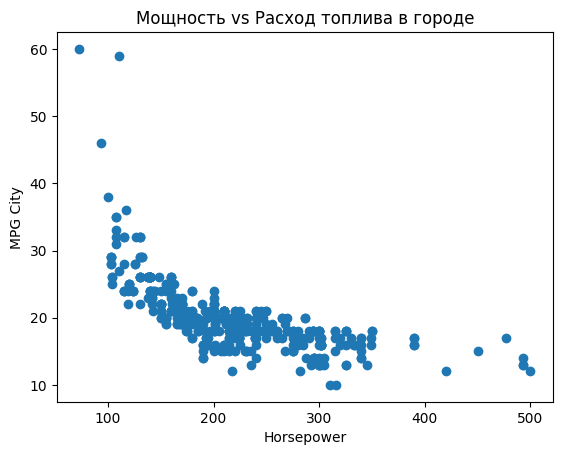

In [127]:
import matplotlib.pyplot as plt
plt.scatter(data['Horsepower'], data['MPG_City'])
plt.xlabel("Horsepower")
plt.ylabel("MPG City")
plt.title("Мощность vs Расход топлива в городе")
plt.show()


<h3>Самые тяжелые и легкие машины

In [128]:
print(data.nlargest(5, 'Weight')[['Make','Model','Weight']])
print(data.nsmallest(5, 'Weight')[['Make','Model','Weight']])


         Make              Model  Weight
118      Ford  Excursion 6.8 XLT    7190
166    Hummer                 H2    6400
143       GMC  Yukon XL 2500 SLT    6133
229   Lincoln   Navigator Luxury    5969
62   Cadillac       Escalade EXT    5879
       Make                       Model  Weight
150   Honda  Insight 2dr (gas/electric)    1850
382  Toyota             Echo 2dr manual    2035
384  Toyota                    Echo 4dr    2055
383  Toyota               Echo 2dr auto    2085
396  Toyota  MR2 Spyder convertible 2dr    2195


<h3>Средняя мощность по типу автомобиля

In [129]:
avg_hp=data.groupby('Type')['Horsepower'].mean()
print(avg_hp)

Type
Hybrid     92.000000
SUV       235.816667
Sedan     201.656489
Sports    284.163265
Truck     224.833333
Wagon     194.000000
Name: Horsepower, dtype: float64


<h3>Максимальная и минимальная цена по типу автомобиля

In [130]:
data.groupby('Type')['MSRP'].min()

Type
Hybrid    19110.0
SUV       17163.0
Sedan     10280.0
Sports    18345.0
Truck     12800.0
Wagon     11905.0
Name: MSRP, dtype: float64

In [131]:
data.groupby('Type')['MSRP'].max()

Type
Hybrid     20510.0
SUV        76870.0
Sedan     128420.0
Sports    192465.0
Truck      52975.0
Wagon      60670.0
Name: MSRP, dtype: float64

<h3>Автомобили с самым большим двигателем

In [132]:
print(data.nlargest(5, 'EngineSize')[['Make','Model','EngineSize','Cylinders']])


          Make                         Model  EngineSize  Cylinders
114      Dodge  Viper SRT-10 convertible 2dr         8.3       10.0
118       Ford             Excursion 6.8 XLT         6.8       10.0
62    Cadillac                  Escalade EXT         6.0        8.0
87   Chevrolet                  Silverado SS         6.0        8.0
143        GMC             Yukon XL 2500 SLT         6.0        8.0


<h3>Топ-5 самых длинных автомобилей

In [133]:
print(data.nlargest(5, 'Length')[['Make','Model','Length']])


          Make                     Model  Length
87   Chevrolet              Silverado SS     238
146        GMC  Sierra Extended Cab 1500     230
118       Ford         Excursion 6.8 XLT     227
314     Nissan         Titan King Cab XE     224
84   Chevrolet            Avalanche 1500     222


<h3>Цена vs Мощность

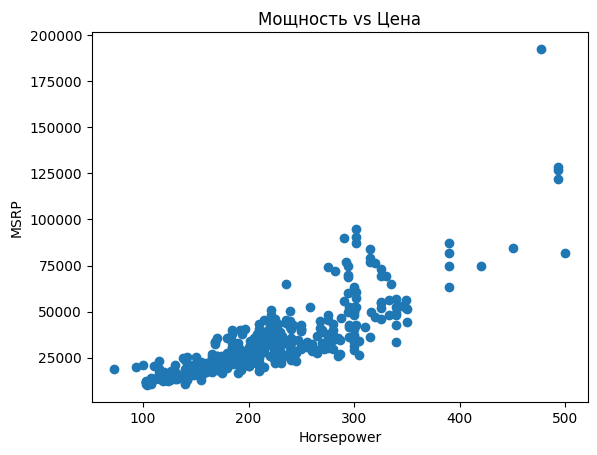

In [134]:
plt.scatter(data['Horsepower'], data['MSRP'])
plt.xlabel('Horsepower')
plt.ylabel('MSRP')
plt.title("Мощность vs Цена")
plt.show()